## Break Through Tech Supply Chain ML Model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)


In [4]:
df = pd.read_csv(r"C:\Users\ngair\Downloads\model_ready_dataset.csv")

In [5]:
df.head()

,trade_volume_tonnes,shipping_delay_days,freight_cost_usd,container_availability_index,port_congestion_index,fuel_cost_index,commodity_price_index,weather_disruption_score,geopolitical_risk_score,carbon_emissions_tonnes,...,destination_region_North America,destination_region_South Asia,origin_income_group_High income,origin_income_group_Low income,origin_income_group_Lower middle income,origin_income_group_Upper middle income,destination_income_group_High income,destination_income_group_Low income,destination_income_group_Lower middle income,destination_income_group_Upper middle income
0,11339.59,6.36,4507.98,96.20,73.21,58.83,28.98,95.92,7.59,4958.80,...,1,0,1,0,0,0,0,1,0,0
1,6844.61,10.61,4593.13,58.07,74.91,58.83,42.49,86.48,83.86,2993.15,...,1,0,1,0,0,0,0,1,0,0
2,8189.89,7.56,4667.95,69.48,80.74,67.90,50.80,25.36,61.04,3581.44,...,1,0,1,0,0,0,0,1,0,0
3,8234.77,8.22,4620.40,69.86,40.05,63.84,53.16,45.26,60.27,3601.06,...,1,0,1,0,0,0,0,1,0,0
4,11022.90,8.00,4523.17,93.52,56.59,57.65,39.04,84.17,12.97,4820.31,...,1,0,1,0,0,0,0,1,0,0


In [6]:
# Target variable
target = "target_disrupted_next_week"

# Separate predictors and target
X = df.drop(columns=[target])
y = df[target]

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(y.value_counts())
print("\nTarget proportions:")
print(y.value_counts(normalize=True))

Dataset shape: (31050, 133)

Target distribution:
target_disrupted_next_week
0    30058
1      992
Name: count, dtype: int64

Target proportions:
target_disrupted_next_week
0    0.968052
1    0.031948
Name: proportion, dtype: float64


In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nTraining observations:", X_train.shape[0])
print("Testing observations:", X_test.shape[0])



Training observations: 23287
Testing observations: 7763


In [8]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

In [9]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [10]:
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"]
}

In [11]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [12]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced_subsample', max_depth=15,
                       min_samples_leaf=2, min_samples_split=5,
                       n_estimators=150, n_jobs=-1, random_state=42)

In [14]:
# Probability of class 1 = disruption next week
y_train_prob = best_rf.predict_proba(X_train)[:, 1]
y_test_prob = best_rf.predict_proba(X_test)[:, 1]

# Classification predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

In [15]:
train_mse = mean_squared_error(y_train, y_train_prob)
test_mse = mean_squared_error(y_test, y_test_prob)

print("MODEL PERFORMANCE")

print(f"In-sample MSE:       {train_mse:.6f}")
print(f"Out-of-sample MSE:  {test_mse:.6f}")


MODEL PERFORMANCE
In-sample MSE:       0.031801
Out-of-sample MSE:  0.051549


In [16]:

train_auc = roc_auc_score(y_train, y_train_prob)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"\nIn-sample ROC-AUC:       {train_auc:.6f}")
print(f"Out-of-sample ROC-AUC:  {test_auc:.6f}")


In-sample ROC-AUC:       0.998411
Out-of-sample ROC-AUC:  0.622566


In [17]:
print("\nConfusion Matrix - Test Set")
print(confusion_matrix(y_test, y_test_pred))


Confusion Matrix - Test Set
[[7417   98]
 [ 226   22]]


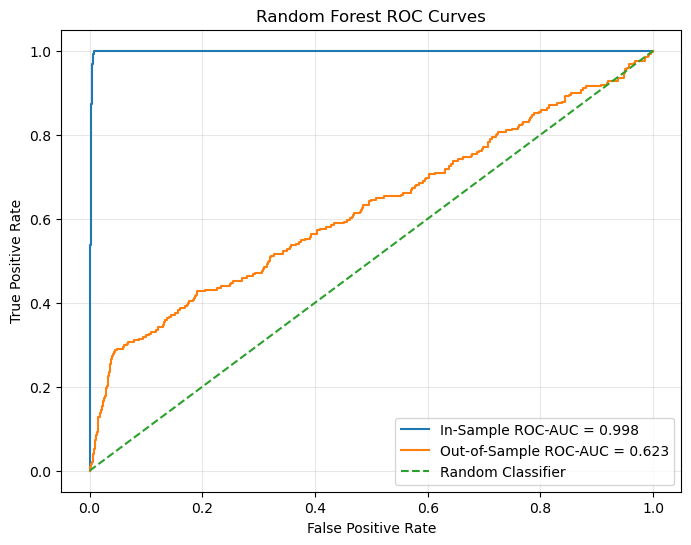

In [18]:
fpr_train, tpr_train, _ = roc_curve(
    y_train,
    y_train_prob
)

fpr_test, tpr_test, _ = roc_curve(
    y_test,
    y_test_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_train,
    tpr_train,
    label=f"In-Sample ROC-AUC = {train_auc:.3f}"
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f"Out-of-Sample ROC-AUC = {test_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


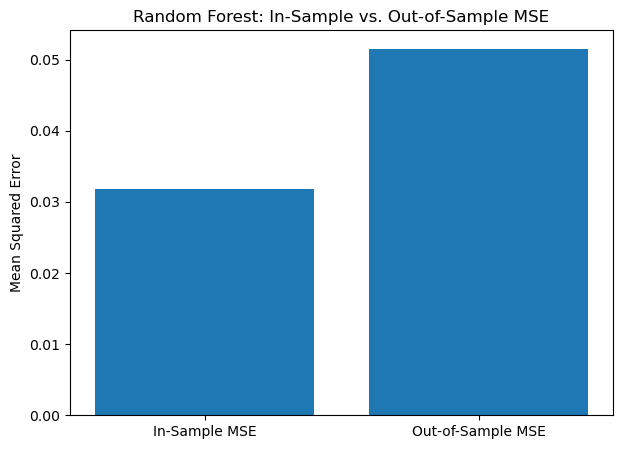

In [19]:

plt.figure(figsize=(7, 5))

plt.bar(
    ["In-Sample MSE", "Out-of-Sample MSE"],
    [train_mse, test_mse]
)

plt.ylabel("Mean Squared Error")
plt.title("Random Forest: In-Sample vs. Out-of-Sample MSE")

plt.show()

In [20]:

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20))



Top 20 Most Important Features:
                                 Feature  Importance
56                     weeks_since_start    0.049208
48                                  year    0.032944
22                             oil_price    0.027921
76  geopolitical_risk_score_rolling4_max    0.022175
67                 freight_cost_usd_lag1    0.019422
2                       freight_cost_usd    0.019380
66          geopolitical_risk_score_lag2    0.018794
59            port_congestion_index_lag1    0.018785
72      shipping_delay_days_rolling4_max    0.018715
68                 freight_cost_usd_lag2    0.017182
71     shipping_delay_days_rolling4_mean    0.017036
65          geopolitical_risk_score_lag1    0.016809
74    port_congestion_index_rolling4_max    0.016785
8                geopolitical_risk_score    0.016579
23                     natural_gas_price    0.016437
64         weather_disruption_score_lag2    0.016254
57              shipping_delay_days_lag1    0.016211
79           

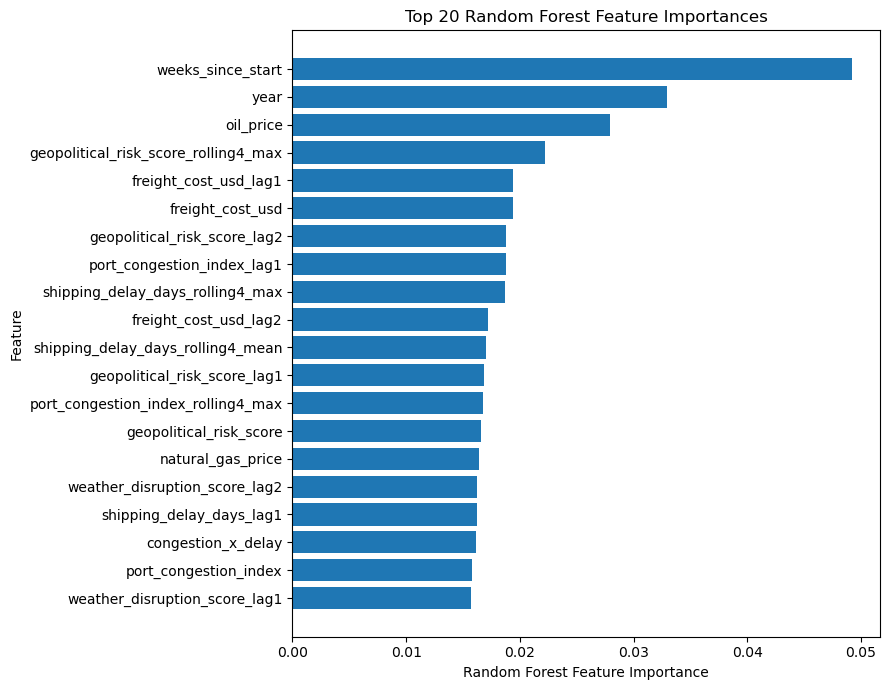

In [21]:
top_features = feature_importance.head(20).sort_values(
    "Importance"
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Random Forest Feature Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()